In [3]:
import numpy as np
from vispy import app, scene, color
from vispy.app import Timer
import jupyter_rfb

# 1. Physical State
state = {
    "x_cart": 0.0,
    "x_target": 0.0,
    "x_velocity": 0.0,
    "theta": 0.3,
    "w": 0.0,
    "l": 1.5,
    "g": 9.81,
    "dt": 1 / 60.0,  # 60 FPS
    "is_dragging": False,
}

# 2. Setup the Canvas
canvas = scene.SceneCanvas(keys="interactive", show=True, bgcolor="#121212")
view = canvas.central_widget.add_view()
view.camera = "panzoom"
view.camera.rect = (-3, -3, 6, 6)

# Create Visuals
# Cart
cart = scene.visuals.Rectangle(
    center=(0, 0, 0),
    width=0.8,
    height=0.4,
    color="white",
    edge_color="cyan",
    parent=view.scene,
)
# Pole
pole = scene.visuals.Line(
    pos=np.array([[0, 0], [0, -1.5]]), color="cyan", width=3, parent=view.scene
)
# Pivot point (handle)
handle = scene.visuals.Markers(parent=view.scene)
handle.set_data(np.array([[0, 0]]), symbol="o", size=15, face_color="magenta")


# 3. Mouse Interaction
@canvas.events.mouse_move.connect
def on_mouse_move(event):
    if event.is_dragging:
        # Map mouse pixels to "Scene" coordinates
        tr = canvas.scene.node_transform(view.scene)
        pos = tr.map(event.pos)[:2]
        state["x_target"] = pos[0]
        state["is_dragging"] = True


@canvas.events.mouse_release.connect
def on_mouse_release(event):
    state["is_dragging"] = False


# 4. Physics & Animation Engine
def update(ev):
    # Calculate hand-driven acceleration
    dx = state["x_target"] - state["x_cart"]
    cart_vel = dx / state["dt"]
    cart_accel = (cart_vel - state["x_velocity"]) / state["dt"]

    state["x_cart"] = state["x_target"]
    state["x_velocity"] = cart_vel

    # Pendulum Physics with Inertial Force
    alpha = (-(state["g"] / state["l"]) * np.sin(state["theta"])) - (
        (cart_accel / state["l"]) * np.cos(state["theta"])
    )

    state["w"] += alpha * state["dt"]
    state["w"] *= 0.98  # Friction
    state["theta"] += state["w"] * state["dt"]

    # Update Visuals
    # Move Cart
    cart.center = (state["x_cart"], 0, 0)
    handle.set_data(
        np.array([[state["x_cart"], 0]]), symbol="o", size=15, face_color="magenta"
    )

    # Move Pole
    px = state["x_cart"] + state["l"] * np.sin(state["theta"])
    py = -state["l"] * np.cos(state["theta"])
    pole.set_data(pos=np.array([[state["x_cart"], 0], [px, py]]))

    canvas.update()


# Create a High-Frequency Timer
timer = Timer(interval=state["dt"], connect=update, start=True)

# Display in Notebook
canvas

RFBOutputContext()

TypeError: CompoundVisual.__init__() got an unexpected keyword argument 'edge_color'

In [17]:
import numpy as np
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, CustomJS, Slider, Button
from bokeh.layouts import column
from bokeh.io import output_notebook

output_notebook()

# 1. Setup Data
L = 1.5
source = ColumnDataSource(
    data={
        "x0": [0.0],
        "y0": [0.0],
        "x1": [0.0],
        "y1": [-L],
        "ground_x": [-5, 5],
        "ground_y": [-0.2, -0.2],
    }
)

# 2. Create Plot
p = figure(
    x_range=(-4, 4),
    y_range=(-2.5, 2.5),
    width=700,
    height=400,
    title="1. Click Start -> 2. Drag Slider to Flick",
    toolbar_location=None,
    background_fill_color="#111111",
)

p.line("ground_x", "ground_y", source=source, color="#333", line_width=2)
p.segment(
    x0="x0", y0="y0", x1="x1", y1="y1", source=source, color="#00ffff", line_width=6
)
p.square("x0", "y0", source=source, size=25, color="white")

# 3. The Game Loop Logic
# This function will run at 60fps once triggered
loop_code = """
    if (!window.sim) {
        window.sim = { th: 0.5, w: 0, v: 0, x_prev: 0, x_target: 0, running: false };
    }
    const s = window.sim;
    const d = source.data;
    const l = 1.5;
    const g = 9.81;
    const dt = 0.016;

    const step = () => {
        // Calculate physics based on slider's position vs previous position
        const v_now = (s.x_target - s.x_prev) / dt;
        const accel = (v_now - s.v) / dt;
        
        s.x_prev = s.x_target;
        s.v = v_now;

        // Pendulum Math (Gravity + Inertia)
        const alpha = (-(g / l) * Math.sin(s.th)) - ((accel / l) * Math.cos(s.th));
        s.w += alpha * dt;
        s.w *= 0.99; // Air resistance
        s.th += s.w * dt;

        // Update visuals
        d['x0'] = [s.x_target];
        d['y0'] = [0];
        d['x1'] = [s.x_target + l * Math.sin(s.th)];
        d['y1'] = [-l * Math.cos(s.th)];

        source.change.emit();
        
        if (s.running) {
            requestAnimationFrame(step);
        }
    };

    if (!s.running) {
        s.running = true;
        step();
    }
"""

# 4. Controls
start_btn = Button(label="► Start Physics", button_type="success", width=100)
start_btn.js_on_click(CustomJS(args=dict(source=source), code=loop_code))

slider = Slider(start=-3, end=3, value=0, step=0.01, title="Flick the Cart")
slider.js_on_change(
    "value",
    CustomJS(
        code="""
    if (!window.sim) { window.sim = { th: 0.5, w: 0, v: 0, x_prev: 0, x_target: 0, running: false }; }
    window.sim.x_target = cb_obj.value;
"""
    ),
)

show(column(start_btn, slider, p))

Loading BokehJS ...

/var/folders/0r/235txxxd1p73wr0r5k9v6mqr0000gn/T/ipykernel_62287/940120677.py:11: BokehUserWarning:

ColumnDataSource's columns must be of the same length. Current lengths: ('ground_x', 2), ('ground_y', 2), ('x0', 1), ('x1', 1), ('y0', 1), ('y1', 1)

/var/folders/0r/235txxxd1p73wr0r5k9v6mqr0000gn/T/ipykernel_62287/940120677.py:37: BokehDeprecationWarning:

'square() method' was deprecated in Bokeh 3.4.0 and will be removed, use "scatter(marker='square', ...) instead" instead.



In [15]:
%matplotlib ipympl

RuntimeError: 'ipympl' is not a recognised GUI loop or backend name

In [13]:
# Run this in your VS Code terminal first:
# pip install sidecar

from sidecar import Sidecar
import fastplotlib as fpl

xs = np.linspace(-10, 10, 100)
ys = np.sin(xs)
# fastplotlib expects a 2D array of shape [n_points, xy] or [n_points, xyz]
data = np.dstack([xs, ys])[0]

# 2. Create a figure/plot area
figure = fpl.Figure(size=(700, 560))

# 3. Add the data to the figure as a line graphic
# figure[0, 0] selects the first subplot in a potential grid layout
sine_wave_graphic = figure[0, 0].add_line(data=data, thickness=3, colors="cyan")

# 4. Show the figure
# ... (use the same fastplotlib code from before) ...

# Instead of fig.show(), use Sidecar
sc = Sidecar(title="Fast Plotting Window")
# with sc:
    # figure.show()

figure.show()

RFBOutputContext()

JupyterRenderCanvas(css_height='560.0px', css_width='700.0px')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Setup the grid
x = np.linspace(-5, 5, 20)
y = np.linspace(-5, 5, 20)
X, Y = np.meshgrid(x, y)


def update_field(q_x, q_y):
    # Calculate distance components
    dx = X - q_x
    dy = Y - q_y
    dist_sq = dx**2 + dy**2
    dist_sq[dist_sq < 0.1] = 0.1  # Softening constant to avoid infinity

    # E-field components (E = k*q / r^2)
    Ex = dx / dist_sq**1.5
    Ey = dy / dist_sq**1.5

    # Plotting
    plt.figure(figsize=(7, 7))
    plt.streamplot(X, Y, Ex, Ey, color="blue", linewidth=1, density=1.2)
    plt.plot(q_x, q_y, "ro", markersize=10)  # The "Charge"
    plt.title(f"Electric Field of a Point Charge at ({q_x}, {q_y})")
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.grid(True)
    plt.show()


# Create the interactive sliders
interact(
    update_field,
    q_x=FloatSlider(value=0, min=-4, max=4, step=0.1),
    q_y=FloatSlider(value=0, min=-4, max=4, step=0.1),
)

interactive(children=(FloatSlider(value=0.0, description='q_x', max=4.0, min=-4.0), FloatSlider(value=0.0, des…

<function __main__.update_field(q_x, q_y)>

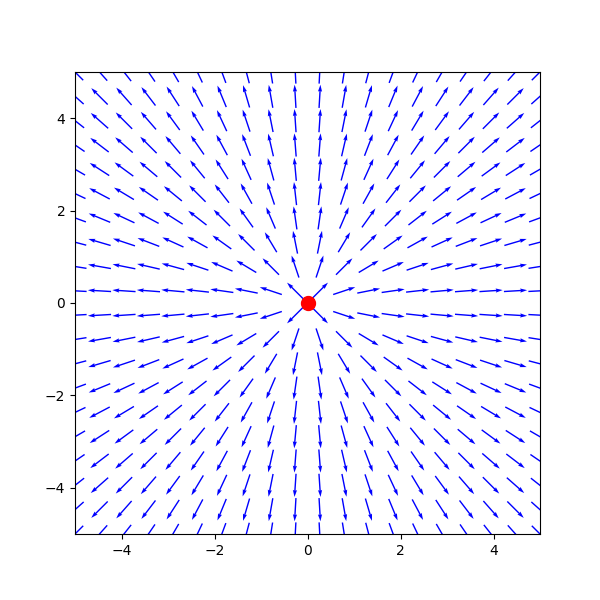

In [16]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the Grid (Reduced density for speed)
x = np.linspace(-5, 5, 20)
y = np.linspace(-5, 5, 20)
X, Y = np.meshgrid(x, y)

class FastFieldSim:
    def __init__(self):
        self.fig, self.ax = plt.subplots(figsize=(6, 6))
        self.q_pos = np.array([0.0, 0.0])
        
        # Initialize the quiver plot with dummy data
        self.qvr = self.ax.quiver(X, Y, np.zeros_like(X), np.zeros_like(Y), 
                                  color='blue', pivot='mid', scale=20)
        self.point, = self.ax.plot([], [], 'ro', markersize=10)
        
        self.ax.set_xlim(-5, 5)
        self.ax.set_ylim(-5, 5)
        
        # Connect events
        self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)
        self.update_field(0, 0)

    def update_field(self, qx, qy):
        dx = X - qx
        dy = Y - qy
        dist_sq = dx**2 + dy**2 + 0.2
        
        # E-field math (vectorized)
        Ex = dx / dist_sq**1.5
        Ey = dy / dist_sq**1.5
        
        # Normalize vectors so they don't overlap too much
        mag = np.sqrt(Ex**2 + Ey**2)
        Ex /= mag
        Ey /= mag

        # UPDATE EXISTING OBJECTS (Faster than clearing the plot)
        self.qvr.set_UVC(Ex, Ey)
        self.point.set_data([qx], [qy])
        self.fig.canvas.draw_idle()

    def on_motion(self, event):
        if event.inaxes == self.ax:
            self.update_field(event.xdata, event.ydata)

sim = FastFieldSim()
plt.show()

In [19]:
%gui qt
import numpy as np
import pyqtgraph as pg
from PySide6 import QtCore

# 1. Create the Application and Window
app = pg.mkQApp("EM Field Sim")
win = pg.GraphicsLayoutWidget(show=True, title="Real-time E-Field")
view = win.addViewBox()
view.setAspectLocked()

# 2. Setup the Grid
x = np.linspace(-5, 5, 20)
y = np.linspace(-5, 5, 20)
X, Y = np.meshgrid(x, y)
X_flat, Y_flat = X.flatten(), Y.flatten()

# 3. Create the Vector Field (CurveItem for arrows)
# We use a ScatterPlotItem for the arrow heads and a PlotCurveItem for the shafts
field = pg.ArrowItem(angle=-90, tipAngle=30, baseAngle=20, brush='b')
arrows = []

# To keep it fast, we'll use a special 'Curve' set for the field
field_plot = pg.ItemGroup()
view.addItem(field_plot)

# 4. Create the Charge (Interactive Point)
charge = pg.ScatterPlotItem(size=20, pen=pg.mkPen(None), brush=pg.mkBrush(255, 0, 0))
charge.addPoints([{'pos': (0, 0), 'data': 1}])
charge.setPos(0, 0)
view.addItem(charge)

def update_field():
    # Get current charge position
    pos = charge.pos()
    qx, qy = pos.x(), pos.y()
    
    # Physics math
    dx = X_flat - qx
    dy = Y_flat - qy
    dist_sq = dx**2 + dy**2 + 0.2
    Ex = dx / dist_sq**1.5
    Ey = dy / dist_sq**1.5
    
    # Update arrow directions
    # (In a full app, you'd use a custom OpenGL shader for max speed, 
    # but for 400 arrows, standard drawing is instant)
    field_plot.clear()
    for i in range(len(X_flat)):
        angle = np.degrees(np.arctan2(Ey[i], Ex[i]))
        a = pg.ArrowItem(pos=(X_flat[i], Y_flat[i]), angle=180-angle, 
                         brush='b', headLen=10)
        field_plot.addItem(a)

# 5. Make it move!
def mouse_moved(evt):
    if charge.contains(evt):
        # Logic to update field on drag
        update_field()

# Initial Draw
update_field()

# This library allows you to literally grab the red dot and move it.
charge.setFlag(charge.GraphicsItemFlag.ItemIsMovable)
charge.sigPlotChanged.connect(update_field)

if __name__ == '__main__':
    pg.exec()

ImportError: 
    Importing PySide6 disabled by IPython, which has
    already imported an Incompatible QT Binding: pyqt5
    

In [21]:
# 1. Tell Jupyter to use the existing PyQt5 event loop
%gui qt5

import numpy as np
import pyqtgraph as pg
from PyQt5 import QtCore, QtWidgets

# 2. Setup the App and Window
# We check if an instance already exists to avoid crashing the kernel
app = QtWidgets.QApplication.instance()
if app is None:
    app = QtWidgets.QApplication([])

win = pg.GraphicsLayoutWidget(show=True, title="Real-time E-Field (PyQt5)")
view = win.addViewBox()
view.setAspectLocked()

# 3. Setup the Grid
res = 15 # Lower resolution = higher FPS
x = np.linspace(-5, 5, res)
y = np.linspace(-5, 5, res)
X, Y = np.meshgrid(x, y)
X_f, Y_f = X.flatten(), Y.flatten()

# 4. Create the Charge (The "Point")
# 'movable=True' is a native pyqtgraph feature for ScatterPlotItems
charge = pg.ScatterPlotItem(size=20, pen='w', brush='r', movable=True)
charge.addPoints([{'pos': (0, 0)}])
view.addItem(charge)

# 5. Create the Vector Field
# We'll use a CurveDataSet for speed or just a list of arrows
arrows = []

def update():
    # Get the position of the first point in the scatter plot
    p1 = charge.points()[0]
    qx, qy = p1.pos().x(), p1.pos().y()
    
    # Physics math (Vectorized)
    dx = X_f - qx
    dy = Y_f - qy
    dist_sq = dx**2 + dy**2 + 0.2
    Ex = dx / dist_sq**1.5
    Ey = dy / dist_sq**1.5
    
    # Normalize for clean visuals
    mag = np.sqrt(Ex**2 + Ey**2)
    Ex, Ey = Ex/mag, Ey/mag

    # Update arrow graphics
    view.items().clear() # Clear old arrows
    view.addItem(charge) # Re-add the charge
    
    for i in range(len(X_f)):
        angle = np.degrees(np.arctan2(Ey[i], Ex[i]))
        # Create a simple arrow
        a = pg.ArrowItem(pos=(X_f[i], Y_f[i]), angle=180-angle, 
                         brush='b', headLen=8, tailLen=10)
        view.addItem(a)

# Connect the "sigPlotChanged" signal to our update function
charge.sigPlotChanged.connect(update)

# Initial draw
update()

# Keep the window on top
win.raise_()
win.activateWindow()

/var/folders/0r/235txxxd1p73wr0r5k9v6mqr0000gn/T/ipykernel_63368/1146563315.py:49: RuntimeWarning: invalid value encountered in divide
  Ex, Ey = Ex/mag, Ey/mag


AttributeError: 'ViewBox' object has no attribute 'items'

In [23]:
import numpy as np
import plotly.graph_objects as go
from ipywidgets import FloatSlider, HBox, VBox

# 1. Setup the Physics Grid
res = 15
x = np.linspace(-5, 5, res)
y = np.linspace(-5, 5, res)
X, Y = np.meshgrid(x, y)
X_f, Y_f = X.flatten(), Y.flatten()

# 2. Create the FigureWidget
fig = go.FigureWidget()

# Add the Vector Field (using 'quiver' style lines)
# We initialize with zeros
fig.add_scatter(
    x=[], y=[], mode="lines", line=dict(color="blue", width=1), name="Field"
)

# Add the Point Charge
fig.add_scatter(
    x=[0], y=[0], mode="markers", marker=dict(size=15, color="red"), name="Charge"
)

fig.update_layout(
    width=600,
    height=600,
    showlegend=False,
    xaxis=dict(range=[-5, 5]),
    yaxis=dict(range=[-5, 5]),
)


# 3. The Update Function
def update_field(change):
    qx, qy = slider_x.value, slider_y.value

    # Physics math
    dx = X_f - qx
    dy = Y_f - qy
    dist_sq = dx**2 + dy**2 + 0.2
    Ex = (dx / dist_sq**1.5) * 0.5  # Scale for visibility
    Ey = (dy / dist_sq**1.5) * 0.5

    # Create line segments for arrows: [start, end, None, start, end, None...]
    # This is a high-performance trick for plotting many lines in one go
    plot_x, plot_y = [], []
    for i in range(len(X_f)):
        plot_x.extend([X_f[i], X_f[i] + Ex[i], None])
        plot_y.extend([Y_f[i], Y_f[i] + Ey[i], None])

    # Update the data without redrawing the whole figure
    fig.data[0].x = plot_x
    fig.data[0].y = plot_y
    fig.data[1].x = [qx]
    fig.data[1].y = [qy]


# 4. Interactive UI
slider_x = FloatSlider(value=0, min=-4.5, max=4.5, step=0.1, description="X")
slider_y = FloatSlider(value=0, min=-4.5, max=4.5, step=0.1, description="Y")

slider_x.observe(update_field, names="value")
slider_y.observe(update_field, names="value")

# Initial call to draw the field
update_field(None)

# Display everything
VBox([fig, HBox([slider_x, slider_y])])

    'data': [{'line': {'color': 'blue', 'width': 1},
              'mode': 'line…

In [1]:
import numpy as np
import plotly.graph_objects as go
from ipywidgets import FloatSlider, VBox
import threading
import time

# --- Physics Constants ---
g = 9.81
L = 2.0
b = 0.5  # Damping (friction)
dt = 0.03  # Time step

# --- State Variables ---
state = {"theta": np.pi / 2, "omega": 0.0, "last_xc": 0.0, "accel_c": 0.0}

# 1. Create FigureWidget
fig = go.FigureWidget()
fig.add_scatter(
    x=[0], y=[0], mode="markers", marker=dict(symbol="square", size=40, color="gray")
)
fig.add_scatter(x=[0, 0], y=[0, 0], mode="lines", line=dict(color="black", width=3))
fig.add_scatter(x=[0], y=[0], mode="markers", marker=dict(size=20, color="red"))

fig.update_layout(
    width=600,
    height=400,
    xaxis=dict(range=[-10, 10]),
    yaxis=dict(range=[-3, 3]),
    showlegend=False,
    template="plotly_white",
)

# 2. UI Control
slider_cart = FloatSlider(value=0, min=-8, max=8, step=0.1, description="Move Cart")


# 3. Physics Loop
def physics_step():
    while True:
        # Calculate Cart Acceleration (Change in position over time)
        current_xc = slider_cart.value
        v_c = (current_xc - state["last_xc"]) / dt
        # Simplified acceleration capture
        accel_c = (current_xc - state["last_xc"]) * 10
        state["last_xc"] = current_xc

        # Pendulum Dynamics (ODE integration)
        # alpha = angular acceleration
        alpha = (
            (-g / L * np.sin(state["theta"]))
            - (accel_c / L * np.cos(state["theta"]))
            - (b * state["omega"])
        )

        state["omega"] += alpha * dt
        state["theta"] += state["omega"] * dt

        # Update Graphics
        xp = current_xc + L * np.sin(state["theta"])
        yp = -L * np.cos(state["theta"])

        with fig.batch_update():
            fig.data[0].x = [current_xc]
            fig.data[1].x, fig.data[1].y = [current_xc, xp], [0, yp]
            fig.data[2].x, fig.data[2].y = [xp], [yp]

        time.sleep(dt)


# Start the background thread for physics
thread = threading.Thread(target=physics_step, daemon=True)
thread.start()

VBox([fig, slider_cart])

    'data': [{'marker': {'color': 'gray', 'size': 40, 'symbol': 'square'},
     …